In [38]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.linalg import ishermitian, eigvals, eigvalsh
from scipy.sparse import kron, eye, diags, csc_matrix, hstack, vstack, random
from scipy.sparse.linalg import expm_multiply, spsolve, norm
from utils import *
from ionq_circuit_utils import *

from os.path import join
import json
import hashlib

from random import seed

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp

from simuq import QSystem
from simuq import Qubit
from simuq.ionq import IonQProvider, IonQAPICircuit

import time

In [41]:
def get_cdf(c_normalized):
    '''Returns the cumulative distribution function for distribution c'''
    assert np.abs(np.sum(c_normalized) - 1) < 1e-5
    cdf = np.zeros_like(c_normalized)
    cdf[0] = c_normalized[0]
    for i in np.arange(1, len(c_normalized)):
        cdf[i] = cdf[i-1] + c_normalized[i]
    return cdf

def sample_from_dist(cdf):
    '''Returns a random index with probability proportional to the distribution according to cdf'''
    u = np.random.rand()
    return np.argmax(u < cdf)

def hamming_weight(bitstring):
    weight = 0
    for bit in bitstring:
        if bit == "1":
            weight += 1
    return weight

In [42]:
DATA_DIR = "experiment_data"
TASK_DIR = "lchs"

CURR_DIR = DATA_DIR
check_and_make_dir(CURR_DIR)
CURR_DIR = join(CURR_DIR, TASK_DIR)
check_and_make_dir(CURR_DIR)

print(CURR_DIR)

use_real_machine = False
if use_real_machine:
    device = "qpu.aria-1"
else:
    device = "simulator"

print("Device:", device)

experiment_data/lchs
Device: simulator


Let $H_{\text{TFIM}} = J\sum_{i=0}^{n-2} Z_j Z_{j+1} + h\sum_{i=0}^{n-1} X_j$.

We consider the non-Hermitian Hamiltonian
$$
H = H_{\text{TFIM}} + i\gamma \sum_{j=0}^{n-1} (Z_j - I).
$$

Experiment parameters

In [43]:
# Experiment parameters
n = 3
J = 1
h = 1
gamma = 0.05                                               # Coefficient for anti-Hermitian part
K = 8                                                   # Right side of bounary
M = 128
T = 2
num_time_points = 16
r = 4                                                   # Trotter steps (should scale with K)
t_vals = np.linspace(0, T, num_time_points)
num_shots = 50
num_samples = 200

print(f"Number of jobs: {num_time_points * num_samples}")
print(f"Estimated cost if using AWS: {num_time_points * num_samples * (0.3 + num_shots * 0.03)}")

experiment_info = {
    "n": n,
    "J": J,
    "h": h,
    "gamma": gamma,
    "K": K,
    "M": M,
    "T": T,
    "num_time_points": num_time_points,
    "r": r,
    "num_shots": num_shots,
    "num_samples": num_samples
}

hash_str = hashlib.md5(json.dumps(experiment_info).encode("utf-8")).hexdigest()
SAVE_DIR = join(CURR_DIR, hash_str)
check_and_make_dir(SAVE_DIR)

print("Save dir:", SAVE_DIR)

with open(join(SAVE_DIR, "experiment_info.json"), "w") as f:
    json.dump(experiment_info, f)
    f.close()

for i in range(num_time_points):
    if not exists(join(SAVE_DIR, f"t_{i}")):
        mkdir(join(SAVE_DIR, f"t_{i}"))


Number of jobs: 3200
Estimated cost if using AWS: 5760.0
Save dir: experiment_data/lchs/17fac7f8cbfa7744651fe90ae49eaf5c


Ground truth

In [44]:
H = h * sum_x(n) + J * sum_J_zz(n, 0.5 * diags([np.ones(n-1), np.ones(n-1)], [1,-1]).toarray()) \
      - 1j * (sum_delta_n(n, delta=2 * gamma * np.ones(n)))

psi_0 = np.zeros(2 ** n)
psi_0[0] = 1
# psi_0 = np.ones(2 ** n)
# psi_0 /= np.linalg.norm(psi_0)

In [45]:
psi = expm_multiply(-1j * H, psi_0, start=0, stop=T, num=num_time_points)

We measure the observable $\sum_{j=0}^{n-1} \frac{I-Z_j}{2}$.

In [46]:
obs_gt = np.zeros(num_time_points)
for i in range(num_time_points):
    obs_gt[i] = np.real(np.conj(psi[i]) @ sum_delta_n(n, np.ones(n)) @ psi[i])

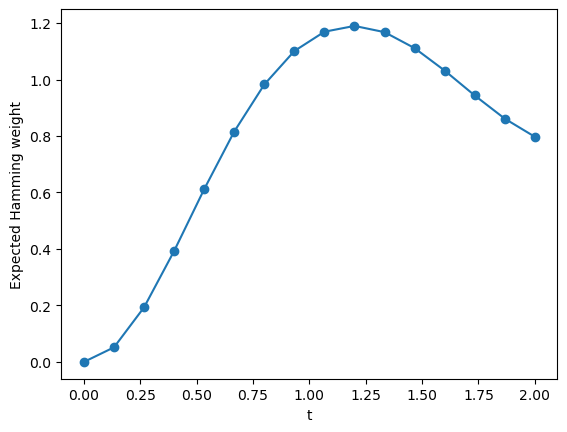

In [47]:
plt.plot(t_vals, obs_gt, '-o', label="Ground truth")
plt.ylabel("Expected Hamming weight")
plt.xlabel("t")
plt.show()

Qiskit implementation

In [48]:
# def diagonal_circuit(n, k, t, J, h, gamma, r=1):
#     # Second order Trotter with r Trotter steps
#     circuit = QuantumCircuit(n)
#     dt = t / r
#     for _ in range(r):
#         # Anti-Hermitian part
#         for i in range(n):
#             circuit.rz(- dt * gamma * k, i)

#         # TFIM part
#         for i in range(n):
#             circuit.rx(2 * dt * h, i)
#         for i in range(n-1):
#             circuit.rzz(2 * dt * J, i, i + 1)
    
#         # Anti-Hermitian part
#         for i in range(n):
#             circuit.rz(- dt * gamma * k, i)
    
#     return circuit

# def off_diagonal_circuit(n, k1, k2, t, J, h, gamma, r=1, compute_real_part=True):
#     assert k1 != k2

#     circuit = QuantumCircuit(n+1)
#     circuit.h(0)
#     if not compute_real_part:
#         circuit.rz(-np.pi/2, 0)

#     dt = t / r
#     # Second-order Trotter
#     for _ in range(r):
#         # TFIM part
#         for i in range(n):
#             circuit.rx(dt * h, 1 + i)
#         for i in range(n-1):
#             circuit.rzz(dt * J, 1 + i, 1 + i + 1)

#         # Anti-Hermitian part
#         a = -2 * dt * gamma * (k1 + k2) / 2
#         b = -2 * dt * gamma * (k1 - k2) / 2
#         for i in range(n):

#             circuit.rz(-b, 0)
#             circuit.rz(a, 1 + i)
#             circuit.h(0)
#             circuit.h(1 + i)
#             circuit.rxx(b, 0, 1 + i)
#             circuit.h(0)
#             circuit.h(1 + i)

#         # TFIM part
#         for i in range(n):
#             circuit.rx(dt * h, 1 + i)
#         for i in range(n-1):
#             circuit.rzz(dt * J, 1 + i, 1 + i + 1)
    
#     circuit.h(0)
#     return circuit


SimuQ implementation

In [49]:
def simuq_diagonal_terms(n, k, t, J, h, gamma):
    qs = QSystem()
    q = [Qubit(qs) for _ in range(n)]
    H = 0

    for j in range(n):
        H += h * q[j].X
    for j in range(n-1):
        H += J * q[j].Z * q[j+1].Z
    for j in range(n):
        H += - gamma * k * q[j].Z
    qs.add_evolution(H, t)
    return qs


def simuq_off_diagonal_terms(n, k1, k2, t, J, h, gamma):
    qs = QSystem()
    q = [Qubit(qs) for _ in range(n+1)]
    H = 0

    # TFIM part
    for j in range(n):
        H += h * q[j+1].X
    for j in range(n-1):
        H += J * q[j+1].Z * q[j+2].Z

    # # Projectors onto \ket{0} and \ket{1}
    p0 = (q[0].I + q[0].Z) / 2
    p1 = (q[0].I - q[0].Z) / 2
    
    for j in range(n):
        H += 2 * gamma * ((k1 * p0 * (np.sign(gamma) * q[j+1].I - q[j+1].Z) / 2) + (k2 * p1 * (np.sign(gamma) * q[j+1].I - q[j+1].Z) / 2))

    qs.add_evolution(H, t)
    return qs

In [50]:
# circuit = diagonal_circuit(n, K, T, J, h, gamma, r)
# compiled_circuit = transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rxx'], optimization_level=3)
# instructions = get_circuit_from_qiskit(compiled_circuit)

# native_instructions, qubit_phase = get_native_circuit(n + 1, instructions)
# single_qubit_gates, two_qubit_gates = get_native_gate_counts(native_instructions)
# print(f"1q: {single_qubit_gates}, 2q: {two_qubit_gates}")

In [51]:
# circuit = off_diagonal_circuit(n, K, -K, T, J, h, gamma, r)
# compiled_circuit = transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rxx'], optimization_level=3)
# instructions = get_circuit_from_qiskit(compiled_circuit)

# native_instructions, qubit_phase = get_native_circuit(n + 1, instructions)
# single_qubit_gates, two_qubit_gates = get_native_gate_counts(native_instructions)
# print(f"1q: {single_qubit_gates}, 2q: {two_qubit_gates}")

In [52]:
# def run_lchs_original(experiment_info, device, save_dir, 
#              job_ids_filename, samples_filename,
#              noisy_simulator=False):
    
#     np.random.seed(0)
    
#     t_vals = np.linspace(0, experiment_info["T"], experiment_info["num_time_points"])
#     k = np.linspace(-experiment_info["K"], experiment_info["K"], experiment_info["M"], endpoint=False)
#     c = 2 * experiment_info["K"] / (experiment_info["M"] * np.pi * (1 + k ** 2))
#     cdf = get_cdf(c / np.sum(c))
    
#     for i, t in enumerate(t_vals):

#         print(f"Running t = {t:0.2f}")

#         job_ids = []
#         sampled_indices = []

#         if i == 0:
#             num_samples = 1
#         else:
#             num_samples = experiment_info["num_samples"]
            
#         for _ in range(num_samples):
#             j1, j2 = sample_from_dist(cdf), sample_from_dist(cdf)
#             sampled_indices.append((int(j1), int(j2)))

#             if j1 == j2:
#                 '''Diagonal terms'''

#                 circuit = diagonal_circuit(experiment_info["n"], k[j1], t, experiment_info["J"], experiment_info["h"], experiment_info["gamma"], r=experiment_info["r"])

#                 compiled_circuit = transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rxx'], optimization_level=3)

#                 instructions = get_circuit_from_qiskit(compiled_circuit)
#                 native_instructions, qubit_phase = get_native_circuit(experiment_info["n"], instructions)
#                 single_qubit_gates, two_qubit_gates = get_native_gate_counts(native_instructions)
#                 # print(f"1q: {single_qubit_gates}, 2q: {two_qubit_gates}")
                
#                 # Create the job json
#                 job = get_ionq_job_json(f"LCHS diagonal term k_{j1}", experiment_info["n"], experiment_info["num_shots"], device, instructions, noisy_simulator=noisy_simulator)
            
#             else:
#                 '''Off-diagonal terms'''

#                 circuit = off_diagonal_circuit(experiment_info["n"], k[j1], k[j2], t, experiment_info["J"], experiment_info["h"], experiment_info["gamma"], r=experiment_info["r"])
#                 compiled_circuit = transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rxx'], optimization_level=3)

#                 instructions = get_circuit_from_qiskit(compiled_circuit)
#                 native_instructions, qubit_phase = get_native_circuit(experiment_info["n"] + 1, instructions)
#                 single_qubit_gates, two_qubit_gates = get_native_gate_counts(native_instructions)
#                 # print(f"1q: {single_qubit_gates}, 2q: {two_qubit_gates}")
            
#                 # Create the job json
#                 job = get_ionq_job_json(f"LCHS off-diagonal term k_{j1}, k_{j2}", experiment_info["n"] + 1, experiment_info["num_shots"], device, instructions, noisy_simulator=noisy_simulator)

#             # Wait before sending the job
#             time.sleep(0.25)

#             # Send the job and get the job id
#             job_id = send_job(job)
#             # print("Job id:", job_id)
#             job_ids.append(job_id)

#         # Save the job ids
#         with open(join(save_dir, f"t_{i}", job_ids_filename), "w") as f:
#             json.dump(job_ids, f)
#             f.close()

#         # Save the sampled indices
#         with open(join(save_dir, f"t_{i}", samples_filename), "w") as f:
#             json.dump(sampled_indices, f)
#             f.close()

#         print()
    
#     print("Finished.")

In [53]:
def run_lchs_original_simuq(experiment_info, device, save_dir, 
             job_ids_filename, samples_filename,
             noisy_simulator=False):
    
    np.random.seed(0)
    
    t_vals = np.linspace(0, experiment_info["T"], experiment_info["num_time_points"])
    k = np.linspace(-experiment_info["K"], experiment_info["K"], experiment_info["M"], endpoint=False)
    c = 2 * experiment_info["K"] / (experiment_info["M"] * np.pi * (1 + k ** 2))
    cdf = get_cdf(c / np.sum(c))

    for i, t in enumerate(t_vals):

        print(f"Running t = {t:0.2f}")

        if i == 0:
            num_samples = 1
        else:
            num_samples = experiment_info["num_samples"]
            
        job_ids = []
        sampled_indices = []
        for _ in range(num_samples):
            
            provider = IonQProvider(api_key=IONQ_API_KEY)

            j1, j2 = sample_from_dist(cdf), sample_from_dist(cdf)
            sampled_indices.append((int(j1), int(j2)))

            if j1 == j2:
                '''Diagonal terms'''
                diagonal_qs = simuq_diagonal_terms(experiment_info["n"], k[j1], t, experiment_info["J"], experiment_info["h"], experiment_info["gamma"])
                provider.compile(diagonal_qs, trotter_mode=2, trotter_num=experiment_info["r"], tol=1)
            else:
                '''Off-diagonal terms'''
                hadamard_circ = IonQAPICircuit(experiment_info["n"]+1)
                hadamard_circ.rz(0, np.pi)
                hadamard_circ.gpi2(0, 0.25 * (2 * np.pi))

                # print(experiment_info["n"], k[j1], k[j2], t, experiment_info["J"], experiment_info["h"], experiment_info["gamma"])
                off_diagonal_qs = simuq_off_diagonal_terms(experiment_info["n"], k[j1], k[j2], t, experiment_info["J"], experiment_info["h"], experiment_info["gamma"])
                assert off_diagonal_qs.num_sites == len(hadamard_circ._accum_phases)
                # try:
                provider.compile(off_diagonal_qs, trotter_mode=2, trotter_num=experiment_info["r"], state_prep=hadamard_circ.copy(), meas_prep=hadamard_circ.copy(), tol=1)
                # except:
                #     print(f"Sample j1={j1}, j2={j2}")
                #     raise Exception()


            # Wait before sending the job
            time.sleep(0.25)
            if device == "simulator":
                provider.run(experiment_info["num_shots"], on_simulator=True, with_noise=noisy_simulator, verbose=-1)
            else:
                provider.run(experiment_info["num_shots"], on_simulator=False, verbose=-1)
            # Get the job id
            job_id = provider.task['id']
            # print("Job id:", job_id)
            job_ids.append(job_id)

        # Save the job ids
        with open(join(save_dir, f"t_{i}", job_ids_filename), "w") as f:
            json.dump(job_ids, f)
            f.close()

        # Save the sampled indices
        with open(join(save_dir, f"t_{i}", samples_filename), "w") as f:
            json.dump(sampled_indices, f)
            f.close()

        print()
    
    print("Finished.")

In [54]:
# def run_lchs_improved_simuq(experiment_info, device, save_dir, 
#              job_ids_filename, samples_filename,
#              noisy_simulator=False):
    
#     np.random.seed(0)
    
#     c = (2 * experiment_info["K"] / experiment_info["M"]) * (1 / (2 * np.pi * np.exp(-2 ** experiment_info["beta"]) * np.exp((1 + 1j*k) ** experiment_info["beta"]))) / (1 - 1j * k)
#     real_part = np.real(np.outer(c, np.conj(c)))
#     imag_part = np.imag(np.outer(c, np.conj(c)))

#     real_part_normalized = np.abs(real_part)
#     real_part_normalized /= np.sum(real_part_normalized)
#     imag_part_normalized = np.abs(imag_part)
#     imag_part_normalized /= np.sum(imag_part_normalized)

#     real_part_cdf = get_cdf(real_part_normalized.flatten())
#     imag_part_cdf = get_cdf(imag_part_normalized.flatten())

#     observable_real_part = np.zeros(len(t_vals))
#     observable_imag_part = np.zeros(len(t_vals))

#     for i, t in enumerate(t_vals):

#         print(f"Running t = {t:0.2f}")

#         if i == 0:
#             num_samples = 1
#         else:
#             num_samples = experiment_info["num_samples"]
            
#         for compute_real_part in [True, False]:
#             job_ids = []
#             sampled_indices = []
#             for _ in range(num_samples):
                
#                 provider = IonQProvider(api_key=IONQ_API_KEY)

#                 if compute_real_part:
#                     idx = sample_from_dist(real_part_cdf)
#                 else:
#                     idx = sample_from_dist(imag_part_cdf)
#                 j1, j2 = idx // experiment_info["M"], idx % experiment_info["M"]
#                 sampled_indices.append((int(j1), int(j2)))

#                 if j1 == j2:
#                     '''Diagonal terms'''
#                     diagonal_qs = simuq_diagonal_terms(experiment_info["n"], k[j1], t, experiment_info["J"], experiment_info["h"], experiment_info["gamma"])
#                     provider.compile(diagonal_qs, trotter_mode=2, trotter_num=experiment_info["r"])
#                 else:
#                     '''Off-diagonal terms'''
#                     hadamard_circ = IonQAPICircuit(experiment_info["n"]+1)
#                     hadamard_circ.rz(0, np.pi)
#                     hadamard_circ.gpi2(0, 0.25 * (2 * np.pi))
#                     # Start with \ket{0} + i \ket{1}
#                     if not compute_real_part:
#                         hadamard_circ.rz(0, -np.pi/2)

#                     print(experiment_info["n"], k[j1], k[j2], t, experiment_info["J"], experiment_info["h"], experiment_info["gamma"])
#                     off_diagonal_qs = simuq_off_diagonal_terms(experiment_info["n"], k[j1], k[j2], t, experiment_info["J"], experiment_info["h"], experiment_info["gamma"])
#                     assert off_diagonal_qs.num_sites == len(hadamard_circ._accum_phases)
#                     # try:
#                     provider.compile(off_diagonal_qs, trotter_mode=2, trotter_num=experiment_info["r"], state_prep=hadamard_circ.copy(), meas_prep=hadamard_circ.copy())
#                     # except:
#                     #     print(f"Sample j1={j1}, j2={j2}")
#                     #     raise Exception()


#                 # Wait before sending the job
#                 time.sleep(0.2)
#                 if device == "simulator":
#                     provider.run(experiment_info["num_shots"], on_simulator=True, with_noise=noisy_simulator)
#                 else:
#                     print("Running on real machine?")
#                     provider.run(experiment_info["num_shots"], on_simulator=False)
#                 # Get the job id
#                 job_id = provider.task['id']
#                 print("Job id:", job_id)
#                 job_ids.append(job_id)

#             # Save the job ids
#             if compute_real_part:
#                 with open(join(save_dir, f"t_{i}_real", job_ids_filename), "w") as f:
#                     json.dump(job_ids, f)
#                     f.close()

#                 # Save the sampled indices
#                 with open(join(save_dir, f"t_{i}_real", samples_filename), "w") as f:
#                     json.dump(sampled_indices, f)
#                     f.close()
#             else:
#                 with open(join(save_dir, f"t_{i}_imag", job_ids_filename), "w") as f:
#                     json.dump(job_ids, f)
#                     f.close()

#                 # Save the sampled indices
#                 with open(join(save_dir, f"t_{i}_imag", samples_filename), "w") as f:
#                     json.dump(sampled_indices, f)
#                     f.close()

#         print()
    
#     print("Finished.")

Classical post-processing

In [55]:
def postprocessing_original(experiment_info, save_dir, job_ids_filename, samples_filename):
    t_vals = np.linspace(0, experiment_info["T"], experiment_info["num_time_points"])
    k = np.linspace(-experiment_info["K"], experiment_info["K"], experiment_info["M"], endpoint=False)
    c = 2 * experiment_info["K"] / (experiment_info["M"] * np.pi * (1 + k ** 2))
    
    observable = np.zeros(len(t_vals))
    std_error = np.zeros(len(t_vals))
    for i, t in enumerate(t_vals):

        # Get the job ids
        with open(join(save_dir, f"t_{i}", job_ids_filename), "r") as f:
            job_ids = json.load(f)
            f.close()
        # Get the sampled indices
        with open(join(save_dir, f"t_{i}", samples_filename), "r") as f:
            sampled_indices = json.load(f)
            f.close()
            
        for j, job_id in enumerate(job_ids):
            j1, j2 = sampled_indices[j]

            # Wait before sending the request
            time.sleep(0.25)
            # Get the results
            results = get_ionq_single_job_result(job_id)

            if j1 == j2:
                
                for string in results.keys():
                    bitstring = np.binary_repr(int(string), experiment_info["n"])
                    # Observable is Hamming weight
                    observable[i] += hamming_weight(bitstring) * results[string]

            else:

                for string in results.keys():
                    bitstring = np.binary_repr(int(string), experiment_info["n"] + 1)
                    if bitstring[-1] == '0':
                        observable[i] += hamming_weight(bitstring[:experiment_info["n"]]) * results[string]
                    else:
                        observable[i] -= hamming_weight(bitstring[:experiment_info["n"]]) * results[string]

                # Compute standard error
                for string in results.keys():
                    bitstring = np.binary_repr(int(string), experiment_info["n"] + 1)
                    if bitstring[-1] == '0':
                        std_error[i] += results[string] * (hamming_weight(bitstring[:experiment_info["n"]]) - observable[i]) ** 2
                    else:
                        std_error[i] += results[string] * (-hamming_weight(bitstring[:experiment_info["n"]]) - observable[i]) ** 2

    observable *= (np.sum(c) ** 2 / experiment_info["num_samples"])
    std_error *= ((np.sum(c) ** 2 / experiment_info["num_samples"]) ** 2)
    std_error = np.sqrt(std_error / (experiment_info["num_shots"] * experiment_info["num_samples"] - 1))

    return observable, std_error

# Run on simulator or real machine

Get gate counts

In [49]:
# t = T
# k = np.linspace(-experiment_info["K"], experiment_info["K"], experiment_info["M"], endpoint=False)
# j1, j2 = 0, 0
# '''Diagonal terms'''

# circuit = diagonal_circuit(experiment_info["n"], k[j1], t, experiment_info["J"], experiment_info["h"], experiment_info["gamma"], r=experiment_info["r"])

# compiled_circuit = transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rxx'], optimization_level=3)

# instructions = get_circuit_from_qiskit(compiled_circuit)
# native_instructions, qubit_phase = get_native_circuit(experiment_info["n"], instructions)
# single_qubit_gates, two_qubit_gates = get_native_gate_counts(native_instructions)
# print(f"1q: {single_qubit_gates}, 2q: {two_qubit_gates}")


# j1, j2 = 0, 1
# '''Off-diagonal terms'''

# circuit = off_diagonal_circuit(experiment_info["n"], k[j1], k[j2], t, experiment_info["J"], experiment_info["h"], experiment_info["gamma"], r=experiment_info["r"])
# compiled_circuit = transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rxx'], optimization_level=3)

# instructions = get_circuit_from_qiskit(compiled_circuit)
# native_instructions, qubit_phase = get_native_circuit(experiment_info["n"] + 1, instructions)
# single_qubit_gates, two_qubit_gates = get_native_gate_counts(native_instructions)
# print(f"1q: {single_qubit_gates}, 2q: {two_qubit_gates}")



IonQ ideal simulator

In [50]:
# device = "simulator"
# job_ids_filename = "job_ids_sim.json"
# samples_filename = "samples_sim.json"
# noisy_simulator = False
# run_lchs_original(experiment_info, device, SAVE_DIR, job_ids_filename, samples_filename, noisy_simulator=noisy_simulator)

IonQ noisy simulator

In [51]:
# device = "simulator"
# job_ids_filename = "job_ids_noisy_sim.json"
# samples_filename = "samples_noisy_sim.json"
# noisy_simulator = True
# run_lchs_original(experiment_info, device, SAVE_DIR, job_ids_filename, samples_filename, noisy_simulator=noisy_simulator)

In [52]:
# observable_ideal, std_error_ideal = postprocessing_original(experiment_info, SAVE_DIR, "job_ids_sim.json", "samples_sim.json")

In [53]:
# observable_noisy, std_error_noisy = postprocessing_original(experiment_info, SAVE_DIR, "job_ids_noisy_sim.json", "samples_noisy_sim.json")

IonQ QPU

In [54]:
# device = "qpu.aria-1"
# job_ids_filename = "job_ids_qpu.json"
# samples_filename = "samples_qpu.json"
# run_lchs_original(experiment_info, device, SAVE_DIR, job_ids_filename, samples_filename)

In [55]:
# observable_qpu, std_error_qpu = postprocessing_original(experiment_info, SAVE_DIR, "job_ids_qpu.json", "samples_qpu.json")

IonQ ideal simulator using SimuQ

In [74]:
device = "simulator"
job_ids_filename = "job_ids_sim_simuq.json"
samples_filename = "samples_sim_simuq.json"
noisy_simulator = False
run_lchs_original_simuq(experiment_info, device, SAVE_DIR, 
             job_ids_filename, samples_filename,
             noisy_simulator=noisy_simulator)

Running t = 0.00

Running t = 0.13

Running t = 0.27

Running t = 0.40

Running t = 0.53

Running t = 0.67

Running t = 0.80

Running t = 0.93

Running t = 1.07

Running t = 1.20

Running t = 1.33

Running t = 1.47

Running t = 1.60

Running t = 1.73

Running t = 1.87

Running t = 2.00

Finished.


In [56]:
observable_sim_simuq, std_error_sim_simuq = postprocessing_original(experiment_info, SAVE_DIR, "job_ids_sim_simuq.json", "samples_sim_simuq.json")

Getting job: cd0fae49-8528-4792-98dc-10f9750e62bf
Job status: completed
Getting job: f55f8a13-c66c-441f-9c43-bf1f5e7ccf42
Job status: completed
Getting job: fcee9359-64fa-4863-a8c2-3e9d478279af
Job status: completed
Getting job: c56a5148-685b-49f7-a15d-3605d7251dd2
Job status: completed
Getting job: 86084ac6-330a-40f8-9e84-37c8069885b0
Job status: completed
Getting job: 9567bddf-da94-42db-aba0-f20e6c16bfef
Job status: completed
Getting job: 34e43257-1807-4e31-ae1b-e07b1898e082
Job status: completed
Getting job: d185a3f6-03e1-4ff4-ac09-5b2a25c5de35
Job status: completed
Getting job: 5ffa69ae-461b-4786-a37d-c801b61a6916
Job status: completed
Getting job: de060bf1-b2a5-483a-8cd7-94a028a0731b
Job status: completed
Getting job: 24bda6ce-3b68-42bf-bd1e-55a54e8f3353
Job status: completed
Getting job: 465221a4-ddb0-4236-9948-f3ac5cbe2d09
Job status: completed
Getting job: 65f08627-8ad0-49d9-81e2-62f658f59640
Job status: completed
Getting job: bd9c5958-557e-4f61-b8f7-1ceff50b9089
Job status: co

IonQ noisy simulator using SimuQ

In [75]:
device = "simulator"
job_ids_filename = "job_ids_noisy_sim_simuq.json"
samples_filename = "samples_noisy_sim_simuq.json"
noisy_simulator = True
run_lchs_original_simuq(experiment_info, device, SAVE_DIR, 
             job_ids_filename, samples_filename,
             noisy_simulator=noisy_simulator)

Running t = 0.00

Running t = 0.13

Running t = 0.27

Running t = 0.40

Running t = 0.53

Running t = 0.67

Running t = 0.80

Running t = 0.93

Running t = 1.07

Running t = 1.20

Running t = 1.33

Running t = 1.47

Running t = 1.60

Running t = 1.73

Running t = 1.87

Running t = 2.00

Finished.


In [57]:
observable_noisy_simuq, std_error_noisy_simuq = postprocessing_original(experiment_info, SAVE_DIR, "job_ids_noisy_sim_simuq.json", "samples_noisy_sim_simuq.json")

Getting job: e5162b76-d20a-43b8-b467-68a227e69beb
Job status: completed
Getting job: a141f164-b394-40e7-aee1-e9649794c5d7
Job status: completed
Getting job: ef0e8dc0-c0d2-463a-8ef5-355e87d1c2bf
Job status: completed
Getting job: bc664271-727d-47be-942f-644178541616
Job status: completed
Getting job: ee5ba782-5e7f-4436-b419-2c939254aa40
Job status: completed
Getting job: 01ef0dbe-06ed-48fa-a5aa-9c4dd4e9b1ec
Job status: completed
Getting job: df467d42-cf94-41fd-8926-671e42c171e8
Job status: completed
Getting job: e63bffbe-fbd4-410f-8e2b-db96c8d90839
Job status: completed
Getting job: 01eb1cd0-92a8-462d-b1f3-92727052121b
Job status: completed
Getting job: 4b3a9d61-47f5-4939-b39e-5ffa4ea633c1
Job status: completed
Getting job: 2c5d58ed-dbcb-4e12-ae5c-8034589f0c98
Job status: completed
Getting job: 16f8d6e5-e1e3-48ad-a50f-cc1f52609604
Job status: completed
Getting job: c264f9ff-21ed-4225-ba5e-14018f863289
Job status: completed
Getting job: 29dbd628-a8de-4cf2-ba68-d3229244e1b2
Job status: co

IonQ QPU using SimuQ

In [76]:
device = "qpu.aria-1"
job_ids_filename = "job_ids_qpu_simuq.json"
samples_filename = "samples_qpu_simuq.json"
run_lchs_original_simuq(experiment_info, device, SAVE_DIR, 
             job_ids_filename, samples_filename)

Running t = 0.00
Running on real machine

Running t = 0.13
Running on real machine
Running on real machine
Running on real machine
Running on real machine
Running on real machine
Running on real machine
Running on real machine
Running on real machine
Running on real machine
Running on real machine
Running on real machine
Running on real machine
Running on real machine
Running on real machine
Running on real machine
Running on real machine
Running on real machine
Running on real machine
Running on real machine
Running on real machine
Running on real machine
Running on real machine
Running on real machine
Running on real machine
Running on real machine
Running on real machine
Running on real machine
Running on real machine
Running on real machine
Running on real machine
Running on real machine
Running on real machine
Running on real machine
Running on real machine
Running on real machine
Running on real machine
Running on real machine
Running on real machine
Running on real machine
Runni

In [58]:
observable_qpu_simuq, std_error_qpu_simuq = postprocessing_original(experiment_info, SAVE_DIR, "job_ids_qpu_simuq.json", "samples_qpu_simuq.json")

Getting job: 6066e6e3-48df-411f-8586-fc3760874e4f
Job status: completed
Getting job: 2d888634-b1af-48ef-8a49-00b2e7b616e4
Job status: completed
Getting job: 04890bc9-f9af-419d-87fc-0abdb54f2d3a
Job status: completed
Getting job: 13fb366c-5b53-4637-a5cd-d64d0af7e909
Job status: completed
Getting job: 2da982dc-c6c0-493a-8ecb-271dc5ff773d
Job status: completed
Getting job: 886a85f0-0990-4ca1-9f4b-2392935bd611
Job status: completed
Getting job: 7cad14c4-d84b-4b8b-b61a-5f5c0189f551
Job status: completed
Getting job: eb439836-85b4-4f80-893a-3bc0afe985f9
Job status: completed
Getting job: f14197d7-10ba-442c-86ea-d7e8af22d72d
Job status: completed
Getting job: 0873e3c0-edca-4688-8344-c8c81965160e
Job status: completed
Getting job: 93434b1a-fcc0-4c9e-badd-a9586a0066db
Job status: completed
Getting job: 52d5a82b-4371-4b96-9110-b359410ed16c
Job status: completed
Getting job: 1d55c86a-d1c8-4ed2-99a1-a3736008ce95
Job status: completed
Getting job: 758755c2-95f1-4638-9038-8225d8aec1a6
Job status: co

# Save data

In [61]:
np.savez(join(SAVE_DIR, "data.npz"), 
         t_vals=t_vals,
         obs_gt=obs_gt,
         observable_sim_simuq=observable_sim_simuq, 
         std_error_sim_simuq=std_error_sim_simuq,
         observable_noisy_simuq=observable_noisy_simuq,
         std_error_noisy_simuq=std_error_noisy_simuq,
         observable_qpu_simuq=observable_qpu_simuq,
         std_error_qpu_simuq=std_error_qpu_simuq)

In [28]:
data = np.load(join(SAVE_DIR, "data.npz"))
observable_sim_simuq = data["observable_sim_simuq"] 
std_error_sim_simuq = data["std_error_sim_simuq"]
observable_noisy_simuq = data["observable_noisy_simuq"]
std_error_noisy_simuq = data["std_error_noisy_simuq"]
observable_qpu_simuq = data["observable_qpu_simuq"]
std_error_qpu_simuq = data["std_error_qpu_simuq"]

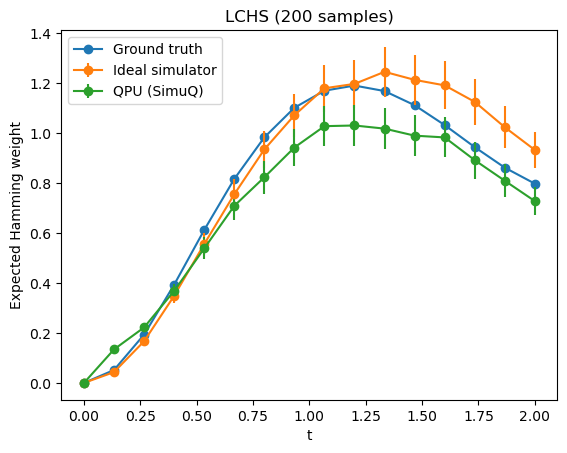

In [62]:
plt.title(f"LCHS ({num_samples} samples)")
plt.plot(t_vals, obs_gt, '-o', label="Ground truth")
plt.errorbar(t_vals, observable_sim_simuq, std_error_sim_simuq, fmt='-o', label="Ideal simulator")
# plt.errorbar(t_vals, observable_qpu, std_error_qpu, fmt='-o', label="IonQ QPU")
# plt.errorbar(t_vals, observable_noisy_simuq, std_error_noisy_simuq, fmt='-o', label="Noisy simulator (SimuQ)")
plt.errorbar(t_vals, observable_qpu_simuq, std_error_qpu_simuq, fmt='-o', label="QPU (SimuQ)")
plt.ylabel("Expected Hamming weight")
plt.xlabel("t")
plt.legend()
plt.show()